# Session 6 — Introduction to Discrete-Event Simulation (SimPy I)

**Course:** Decision Modelling — Simulation Part
**Session:** 6 of 12 (simulation portion)

## Learning objectives

By the end of this session you should be able to:

- Explain the core building blocks of Discrete-Event Simulation: events, processes, and resources
- Implement a simple DES model in SimPy
- Track events, queue behavior, and performance metrics from a running simulation

## Where this session fits

- **Looking back:** Session 5 gave us exact formulas for M/M/1 and M/M/c queues. Today we build the *same kind of system* — a single-server queue — in code, so we can (a) verify it reproduces those formulas, and (b) later extend it far beyond what closed-form formulas can handle.
- **This is your first full DES model.** Everything from here through Session 11 builds on the pattern you'll write today.
- **Looking ahead:** Session 7 extends this to multiple servers and more complex queues; Sessions 8–9 give the statistical rigor for interpreting simulation output that today's model deliberately simplifies.

## A note on how this topic is taught

There is no required textbook for the SimPy portion of this course. The authoritative reference for SimPy itself is its official documentation (https://simpy.readthedocs.io), and how-to demonstrations are provided separately as instructor screencasts. This notebook focuses on the *concepts* and *decision-modeling framing* around SimPy, using just enough of the library to build a complete, correct model — treat the official docs as the place to go for anything SimPy-specific beyond what's used here.


## 1. Why move beyond formulas?

Session 5's formulas are exact, but only for tidy special cases: Poisson arrivals, exponential service, a fixed number of identical servers, infinite queue space, simple FCFS discipline. Real OSCM systems are rarely this clean: arrival rates change over the day, service times follow other distributions, queues have finite capacity, customers might balk or renege, and systems have multiple interacting stages.

**Discrete-Event Simulation (DES) lets us build a model of the system's actual logic** — step by step, event by event — and *measure* the performance metrics we'd otherwise need a formula for. The trade-off: we no longer get an exact answer instantly: we get an *estimate*, with the same kind of statistical uncertainty Monte Carlo taught us to take seriously in Sessions 3–4.


## 2. Core SimPy concepts

SimPy models a system as a collection of **processes** that interact through **events**, all coordinated by a simulated clock (the **environment**).

- **Environment (`simpy.Environment`)** — holds the simulation clock and coordinates all events. `env.now` gives the current simulated time.
- **Process** — a Python **generator function** (uses `yield`) describing a sequence of things that happen to one entity over time (e.g. "a customer arrives, waits for a server, gets served, leaves"). Every `yield` pauses the process until the yielded event occurs, then execution resumes.
- **Events** — the two you'll use constantly:
  - `env.timeout(duration)` — "wait for `duration` simulated time units" (e.g. a service time)
  - a **resource request** — "wait until a resource becomes available"
- **Resource (`simpy.Resource`)** — models limited capacity (e.g. one server). `resource.request()` asks for the resource; the process waits (yields) until it's granted, does its work, then releases it.

The pattern `yield env.timeout(...)` or `yield resource.request()` is the entire mechanical core of SimPy — nearly every model you'll build in this course is a variation on processes that `yield` on timeouts and resource requests.


In [1]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial

print(f"SimPy version: {simpy.__version__}")


SimPy version: 4.1.2


## 3. Building the model, piece by piece

### 3.1 A single customer's journey

Let's start with the process for **one customer**: arrive, request the server, wait if necessary, get served, leave. We'll record what happened to each customer in a shared list.


In [2]:
def customer(env, name, server, mean_service_time, rng, records):
    arrival_time = env.now

    with server.request() as req:
        yield req  # wait here until the server is free
        wait_time = env.now - arrival_time

        service_time = rng.exponential(mean_service_time)
        yield env.timeout(service_time)  # occupy the server for the service duration

    departure_time = env.now
    records.append({
        'name': name,
        'arrival_time': arrival_time,
        'wait_time': wait_time,
        'service_time': service_time,
        'departure_time': departure_time,
        'time_in_system': departure_time - arrival_time,
    })


### 3.2 Generating a stream of customers

We also need a process that creates customers over time, with exponential interarrival times (matching the Poisson-arrivals assumption from Session 5's M/M/1 model).


In [3]:
def customer_generator(env, mean_interarrival_time, server, mean_service_time, rng, records):
    customer_id = 0
    while True:
        yield env.timeout(rng.exponential(mean_interarrival_time))
        customer_id += 1
        env.process(customer(env, customer_id, server, mean_service_time, rng, records))


### 3.3 Assembling and running the model

Now we wire everything together: create an environment, a single-server `Resource` (`capacity=1`), start the customer generator, and run the simulation for a fixed amount of simulated time.

We'll use `lambda = 1/5 per minute` (mean interarrival time 5 minutes) and `mu = 1/4 per minute` (mean service time 4 minutes), giving `rho = 0.8` — a moderately busy, stable single-server queue.


In [4]:
mean_interarrival = 5.0   # minutes  (lambda = 1/5 per minute)
mean_service = 4.0        # minutes  (mu = 1/4 per minute)
run_length = 5000.0       # minutes

rng = np.random.default_rng(seed=42)

env = simpy.Environment()
server = simpy.Resource(env, capacity=1)
records = []

env.process(customer_generator(env, mean_interarrival, server, mean_service, rng, records))
env.run(until=run_length)

df = pd.DataFrame(records)
print(f"Number of customers who completed service: {len(df)}")
df.head()


Number of customers who completed service: 1017


,name,arrival_time,wait_time,service_time,departure_time,time_in_system
0,1,12.021043,0.0,9.539044,21.560087,9.539044
1,2,23.701991,0.0,0.345750,24.047741,0.345750
2,3,25.100963,0.0,5.639843,30.740806,5.639843
3,4,32.364265,0.0,0.317177,32.681442,0.317177
4,5,47.985745,0.0,0.281745,48.267490,0.281745


## 4. Computing performance metrics from simulation output

From the recorded data, we can compute exactly the KPIs Session 5 gave us formulas for:

- **Throughput (TH):** completions per unit time
- **Average time in system (W):** mean of `time_in_system`
- **Average wait time (Wq):** mean of `wait_time`
- **Utilization (rho):** fraction of time the server was busy


In [5]:
TH = len(df) / run_length
W = df['time_in_system'].mean()
Wq = df['wait_time'].mean()
utilization = df['service_time'].sum() / run_length

print(f"Throughput (TH):        {TH:.4f} customers/minute  (target lambda = {1/mean_interarrival:.4f})")
print(f"Avg time in system (W): {W:.4f} minutes")
print(f"Avg wait time (Wq):     {Wq:.4f} minutes")
print(f"Utilization (rho):      {utilization:.4f}")


Throughput (TH):        0.2034 customers/minute  (target lambda = 0.2000)
Avg time in system (W): 19.7542 minutes
Avg wait time (Wq):     15.5546 minutes
Utilization (rho):      0.8542


## 5. Verification: does this match the M/M/1 formulas?

This is the payoff from Session 5: since our model matches the M/M/1 assumptions (Poisson arrivals, exponential service, one server), we can directly compare our simulated results to the exact formulas.


In [6]:
def mm1(lam, mu):
    rho = lam / mu
    P0 = 1 - rho
    L = rho / (1 - rho)
    Lq = rho**2 / (1 - rho)
    W = 1 / (mu - lam)
    Wq = rho / (mu - lam)
    return {'rho': rho, 'P0': P0, 'L': L, 'Lq': Lq, 'W': W, 'Wq': Wq}

lam = 1 / mean_interarrival
mu = 1 / mean_service
theory = mm1(lam, mu)

comparison = pd.DataFrame({
    'Simulated': {'rho': utilization, 'W': W, 'Wq': Wq},
    'Theoretical (M/M/1)': {'rho': theory['rho'], 'W': theory['W'], 'Wq': theory['Wq']}
})
print(comparison.round(4))


     Simulated  Theoretical (M/M/1)
rho     0.8542                  0.8
W      19.7542                 20.0
Wq     15.5546                 16.0


If the simulated and theoretical values are reasonably close, this is genuine evidence our model is behaving as intended — the **verification** step promised back in Session 5. They won't match *exactly*: our simulation is a single run of finite length, so there's sampling variability, just like every Monte Carlo estimate in Sessions 3–4. (How much variability is "acceptable," and how to run this properly with replications, is exactly what Session 8 formalizes — today we're just doing a first, informal check.)


## 6. An independent check: Little's Law via direct monitoring

So far we've computed `W` and `TH` from customer records, but haven't independently measured `L` (average number in system) — computing it as `TH x W` would just be restating Little's Law algebraically, not testing it. Let's measure `L` a genuinely different way: **periodically sample** the number of customers in the system directly from the resource, using a separate monitoring process.


In [7]:
def monitor(env, server, sample_interval, samples):
    while True:
        samples.append((env.now, server.count + len(server.queue)))
        yield env.timeout(sample_interval)

# Re-run the model with a monitor process added
rng2 = np.random.default_rng(seed=42)
env2 = simpy.Environment()
server2 = simpy.Resource(env2, capacity=1)
records2 = []
samples = []

env2.process(customer_generator(env2, mean_interarrival, server2, mean_service, rng2, records2))
env2.process(monitor(env2, server2, sample_interval=0.5, samples=samples))
env2.run(until=run_length)

samples_df = pd.DataFrame(samples, columns=['time', 'number_in_system'])
L_measured = samples_df['number_in_system'].mean()

df2 = pd.DataFrame(records2)
W2 = df2['time_in_system'].mean()
TH2 = len(df2) / run_length

print(f"L, measured directly by sampling:  {L_measured:.4f}")
print(f"TH x W (Little's Law prediction):  {TH2 * W2:.4f}")
print(f"L, theoretical (M/M/1):             {theory['L']:.4f}")


L, measured directly by sampling:  4.0246
TH x W (Little's Law prediction):  4.0180
L, theoretical (M/M/1):             4.0000


All three numbers should be reasonably close: a genuinely independent measurement (direct sampling), an algebraic identity check (`TH x W`), and the closed-form theory. Small discrepancies are expected from finite-length simulation and from starting the system empty (Session 9 will address exactly this "warm-up" issue rigorously).

Let's also look at the number-in-system trace directly:


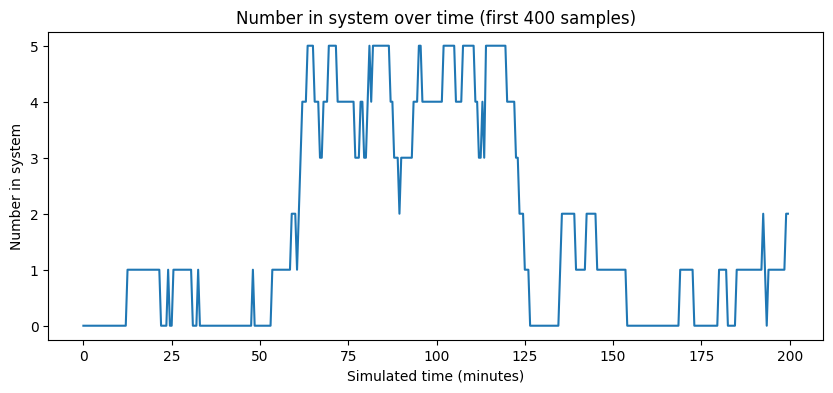

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(samples_df['time'][:400], samples_df['number_in_system'][:400])
plt.xlabel('Simulated time (minutes)')
plt.ylabel('Number in system')
plt.title('Number in system over time (first 400 samples)')
plt.show()


## Exercise (guided): how does utilization affect waiting?

Session 5's formulas predict that waiting time grows sharply as utilization (`rho`) approaches 1. Let's confirm this with the simulation itself, rather than just trusting the formula.

Your task:

1. For each `rho` in `[0.5, 0.6, 0.7, 0.8, 0.9]`, set `mean_interarrival = mean_service / rho` (keeping `mean_service = 4.0` fixed) so that utilization equals the target `rho`
2. Run the model (reuse `customer_generator` and a fresh `simpy.Environment`/`Resource` each time) for `run_length = 5000`
3. Record the simulated average wait time `Wq` for each `rho`
4. Plot simulated `Wq` vs. `rho`, and overlay the theoretical M/M/1 `Wq` curve from `mm1()` for comparison


In [9]:
# EXERCISE
rho_values = [0.5, 0.6, 0.7, 0.8, 0.9]
mean_service_fixed = 4.0

# TODO: for each target rho, compute mean_interarrival, run a fresh simulation,
#       and record the simulated average wait time (Wq)

# TODO: also compute the theoretical Wq for each rho using mm1()

# TODO: plot simulated Wq and theoretical Wq (as two lines/markers) vs rho


<details>
<summary>Solution (click to expand)</summary>

```python
# SOLUTION
rho_values = [0.5, 0.6, 0.7, 0.8, 0.9]
mean_service_fixed = 4.0

sim_wq = []
theory_wq = []

for rho in rho_values:
    mean_interarrival_rho = mean_service_fixed / rho

    rng_rho = np.random.default_rng(seed=42)
    env_rho = simpy.Environment()
    server_rho = simpy.Resource(env_rho, capacity=1)
    records_rho = []

    env_rho.process(customer_generator(env_rho, mean_interarrival_rho, server_rho,
                                        mean_service_fixed, rng_rho, records_rho))
    env_rho.run(until=5000.0)

    df_rho = pd.DataFrame(records_rho)
    sim_wq.append(df_rho['wait_time'].mean())

    lam_rho = 1 / mean_interarrival_rho
    mu_rho = 1 / mean_service_fixed
    theory_wq.append(mm1(lam_rho, mu_rho)['Wq'])

plt.figure(figsize=(8, 5))
plt.plot(rho_values, sim_wq, 'o-', label='Simulated Wq')
plt.plot(rho_values, theory_wq, 's--', label='Theoretical Wq (M/M/1)')
plt.xlabel('Utilization (rho)')
plt.ylabel('Average wait time (Wq)')
plt.title('Wait time grows sharply as utilization approaches 1')
plt.legend()
plt.show()
```
</details>


### Discussion questions

1. Why does `Wq` grow so much faster than linearly as `rho` approaches 1? What does this imply for a manager tempted to run a system "as efficiently as possible" (i.e. at very high utilization)?
2. We started the simulation with an empty system (`env.run(until=...)` from a system with zero customers at `t=0`). Do you think this affects our estimates more at low `rho` or high `rho`? Why might this matter more for shorter simulation runs?
3. Everything in this notebook assumed `server.request()` grants access strictly in arrival order (FCFS) — is that actually guaranteed by `simpy.Resource`, and would it matter for the metrics we computed?


## Wrap-up

Today we:

- Explained SimPy's core building blocks: environment, processes (generator functions with `yield`), events (`timeout`, resource requests), and resources
- Built a complete single-server queue DES model from scratch
- Computed throughput, wait time, time in system, and utilization directly from simulation output
- **Verified** the model against Session 5's M/M/1 formulas — both directly and via an independent measurement of `L` to check Little's Law
- Explored how waiting time behaves as utilization increases, entirely from simulation (not just the formula)

**Next session:** DES Modeling in SimPy II: Multi-Server & Complex Queues — we extend today's single-server model to multiple servers (M/M/c-like systems), enabling comparisons like the pooled-vs-dedicated capacity result from Session 5, but now for systems too complex for closed-form formulas.
